## Preprocessing

### Data Loading
Loading EEG Data using MNE 

In [1]:
import mne
import edfio
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from pyarrow.parquet import ParquetFile
from mne.io import concatenate_raws, read_raw_edf
mne.set_log_level('error')


from bscarlos.settings import RAW_KISPI_DATA_FOLDER
from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER

#### European data format (.edf)
Loading EDF and EDF+ files

Simple load of an .edf file from an absolute path

In [2]:
file = 'C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\SE021_150901U-C.edf'
raw = mne.io.read_raw_edf(file, preload=True)
# Copy of the raw data to preserve original data
original_raw = raw.copy()

The `raw` object is MNE'S cord dat structure for continuous EEG data.  

It hold the raw EEG signal, channel information (names, types, positions), sampling rate and optional event markers/annotations.

In [3]:
# View raw data attributes
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F7, EEG F3, EEG Fz, EEG F4, EEG F8, EEG ...
 chs: 24 EEG
 custom_ref_applied: False
 highpass: 0.2 Hz
 lowpass: 100.0 Hz
 meas_date: 2015-09-01 16:06:27 UTC
 nchan: 24
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

In [4]:
raw.info.keys()

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])

In [5]:
raw.info['sfreq']

256.0

Our data is sampled at 256Hz, meaning that there are 256 measurements per second. 

Which means that each measurment is 1/256th of a second or 4ms.

So to dereive the length of the EEG recording (`scan_duration`), in seconds, we divide the number of time points by the sampling rate.

In [6]:
raw._data.shape

(24, 368640)

In [7]:
scan_duration = raw._data.shape[1] / raw.info['sfreq']
print('Duration of EEG recording = ', scan_duration, ' seconds, or', round(scan_duration / 60, 2), 'minutes')

Duration of EEG recording =  1440.0  seconds, or 24.0 minutes


Using `.get_data()` method of the `raw` object allows to specify wanted time range, in seconds, and will return the data in that time range.

Use `tmin` and `tmax` kwargs to specify the time range, and `picks` kwarg to select the desired channel.

In [8]:
raw.get_data(picks='EEG Pz',tmin=1, tmax=5)

array([[ 6.35408560e-06,  1.29766537e-05,  1.87042802e-05, ...,
        -5.57548638e-05, -5.34280156e-05, -5.25330739e-05]])

#### Parquet format (.parquet)

In [9]:
file = PROCESSED_KISPI_DATA_FOLDER / Path('6_channel') / 'SE008_a1_6ch.parquet'

In [10]:
pfile = pq.read_table(file)
print("Column names: {}".format(pfile.column_names))
print("Schema: {}".format(pfile.schema))

Column names: ['EEG Fp1', 'EEG Fp2', 'EEG F7', 'EEG F3', 'EEG Fz', 'EEG F4', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG O1', 'EEG O2', '__index_level_0__']
Schema: EEG Fp1: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp1", "dimension": "uV", "sample_rat' + 210
EEG Fp2: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fp2", "dimension": "uV", "sample_rat' + 210
EEG F7: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F7", "dimension": "uV", "sample_rate' + 209
EEG F3: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F3", "dimension": "uV", "sample_rate' + 209
EEG Fz: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG Fz", "dimension": "uV", "sample_rate' + 209
EEG F4: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F4", "dimension": "uV", "sample_rate' + 209
EEG F8: float
  -- field metadata --
  edf_signal_header: '{"label": "EEG F8", "dimension": "uV", "sample_rate' + 

### Visualizing raw EEG data

#### Plot EEG data wit MNE

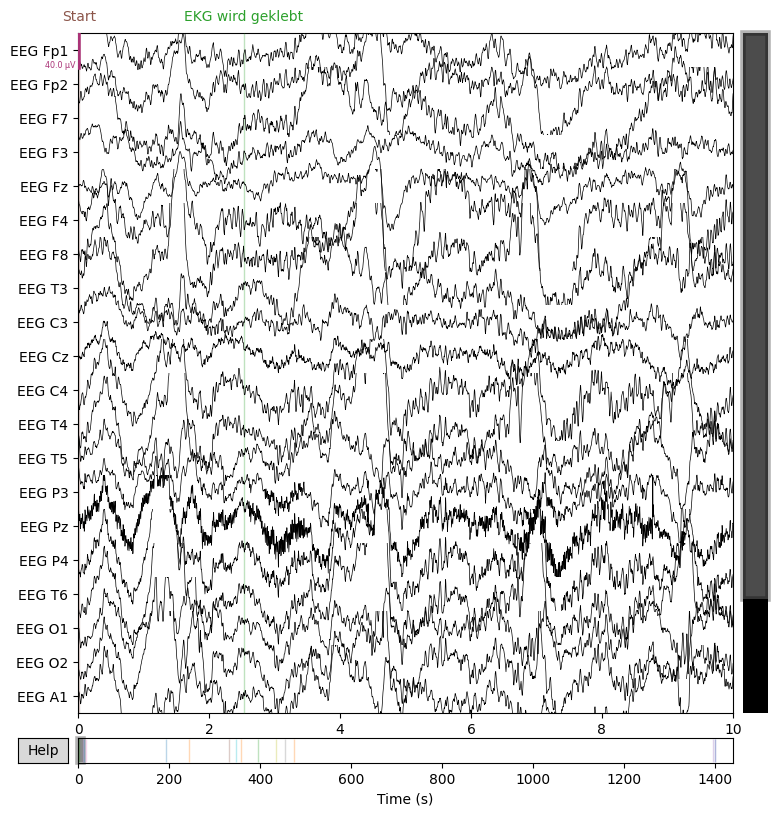

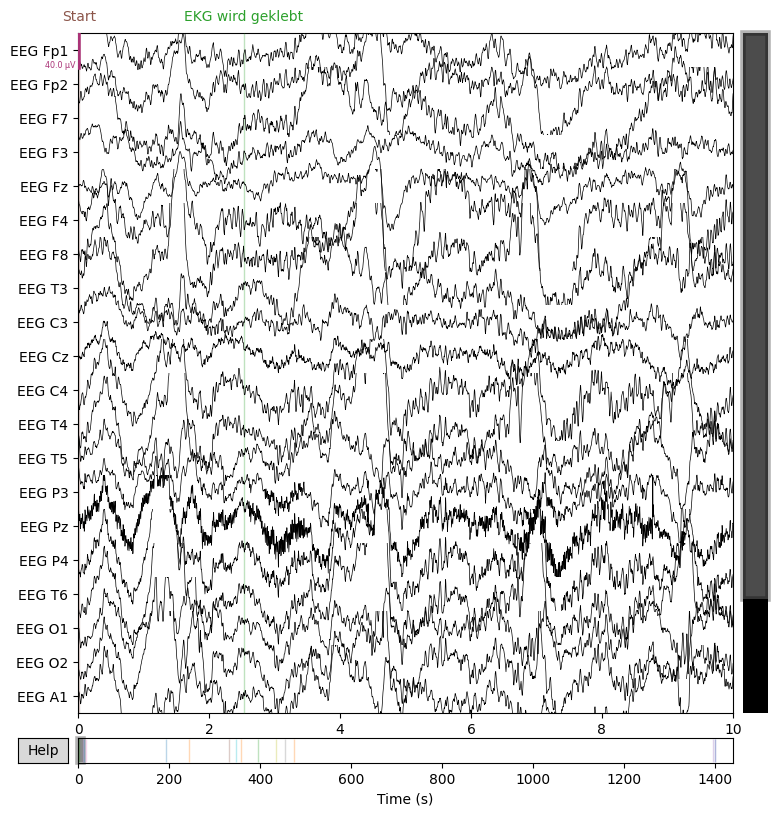

In [11]:
# Plot the raw EEG data
raw.plot()

#### Plot EEG data with Matplotlib

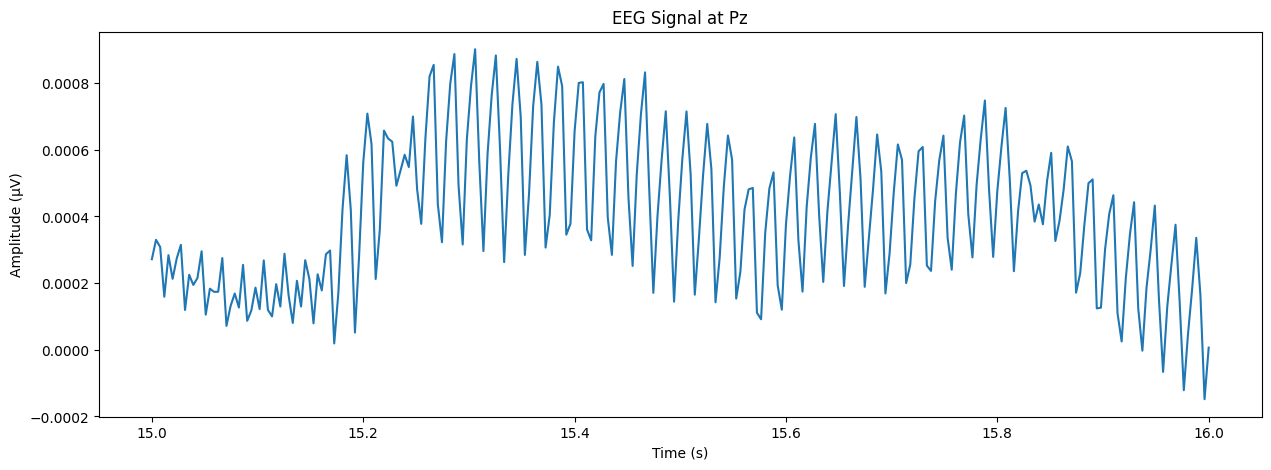

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
# Plotting a single channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 15
end_time = 16
# Get the data from channel Pz, from 1500 - 1600 ms
data = raw.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T
# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

ax.plot(times, data)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()


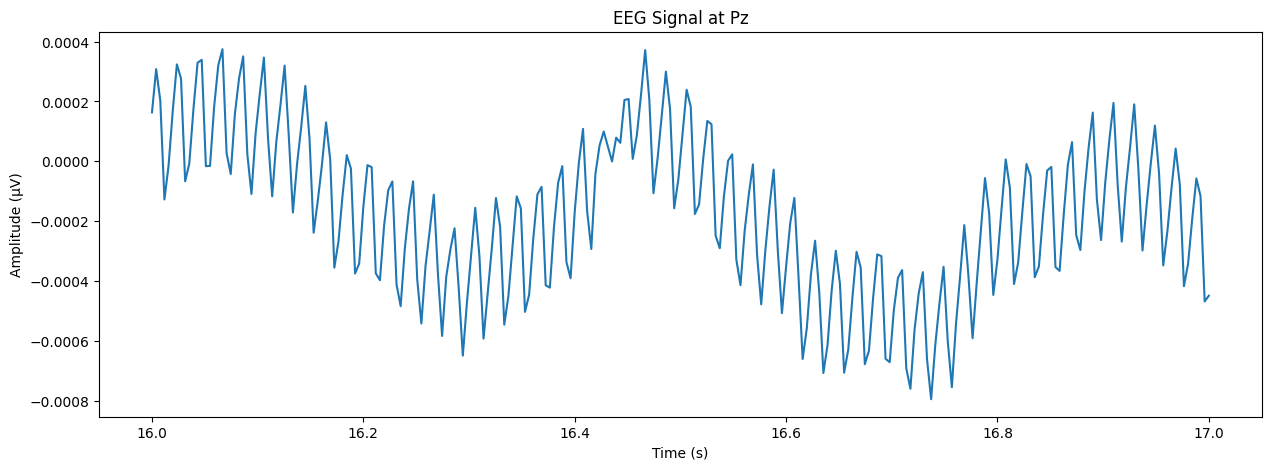

In [13]:
# Plotting a single channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 16
end_time = 17
# Get the data from channel Pz, from 1600 - 1700 ms
data = raw.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T
# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

ax.plot(times, data)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()

### Filtering

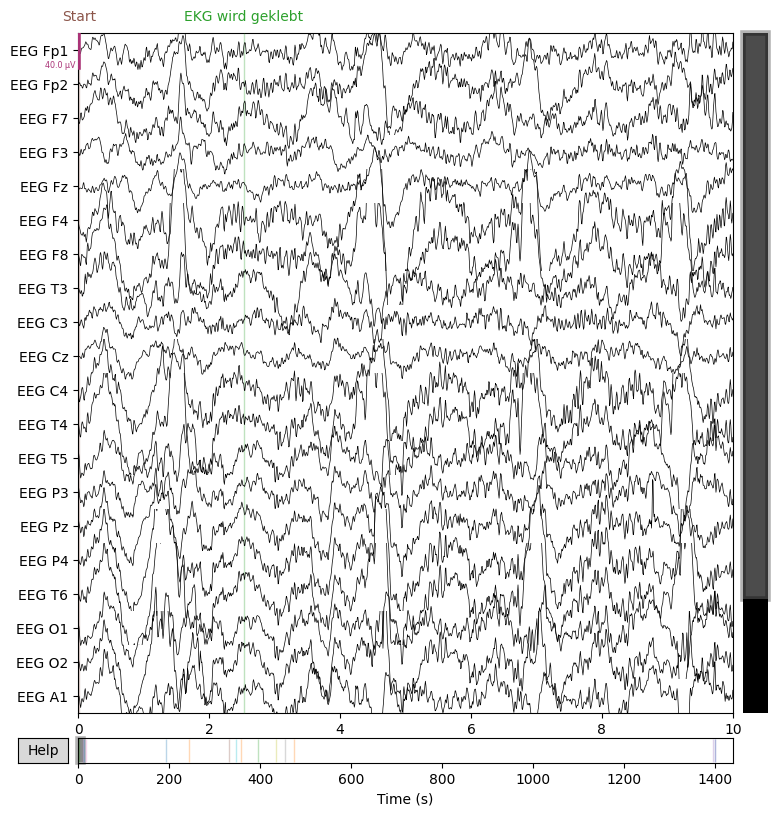

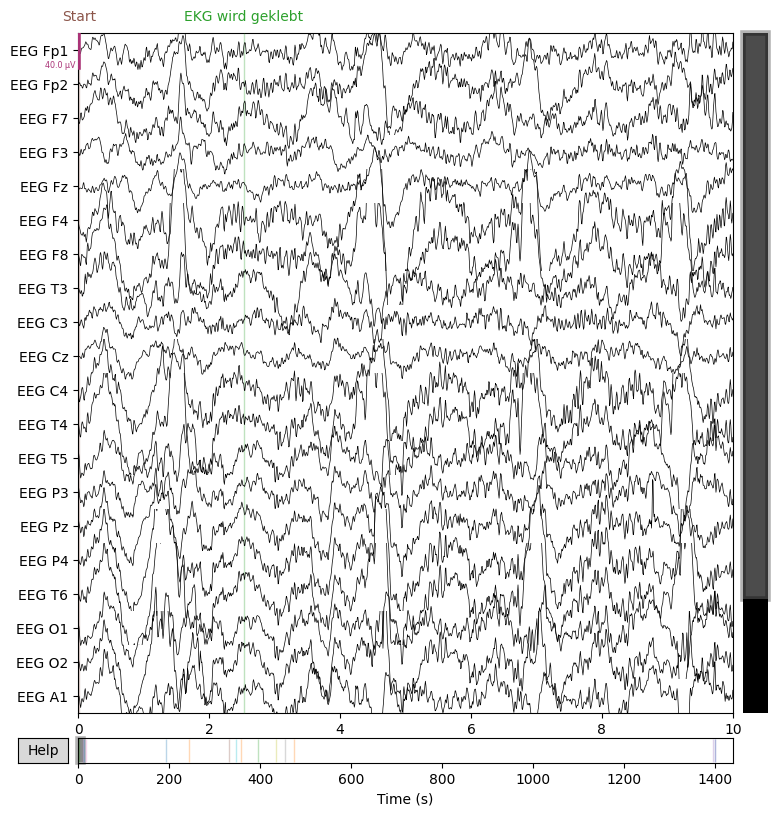

In [14]:
raw_filtered = raw.filter(1, 40)
raw_filtered.plot()

#### Single channel filtered

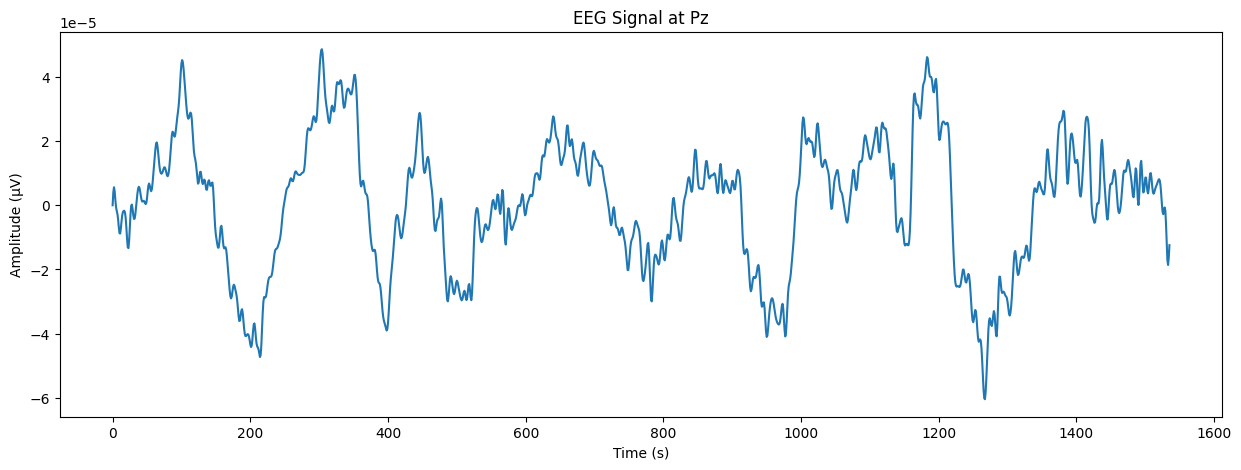

In [15]:
# Plotting a single (filterd) channel
fig, ax = plt.subplots(figsize=[15, 5])

start_time = 0
end_time = 6

ax.plot(raw_filtered.get_data(picks='EEG Pz',tmin=start_time, tmax=end_time).T)
ax.set_title('EEG Signal at Pz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
plt.show()

In [16]:
def plot_eeg_signal(raw, channel, start_time, end_time, title=None, filtered=False):
    """
    Plot EEG signal from a specific channel.

    Parameters:
    raw (mne.io.Raw): Raw EEG data.
    channel (str): Channel name (e.g. 'EEG Pz').
    start_time (float): Start time of the plot in seconds.
    end_time (float): End time of the plot in seconds.
    title (str, optional): Plot title. Defaults to None.
    filtered (bool, optional): Whether to use filtered data. Defaults to False.
    """
    fig, ax = plt.subplots(figsize=[15, 5])

    if filtered:
        data = raw.filter(1, 40).get_data(picks=channel, tmin=start_time, tmax=end_time).T
    else:
        data = raw.get_data(picks=channel, tmin=start_time, tmax=end_time).T

    ax.plot(data)
    ax.set_title(title or f'EEG Signal at {channel}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (μV)')
    plt.show()

#### View EEG channel unfiltered vs. filtered 

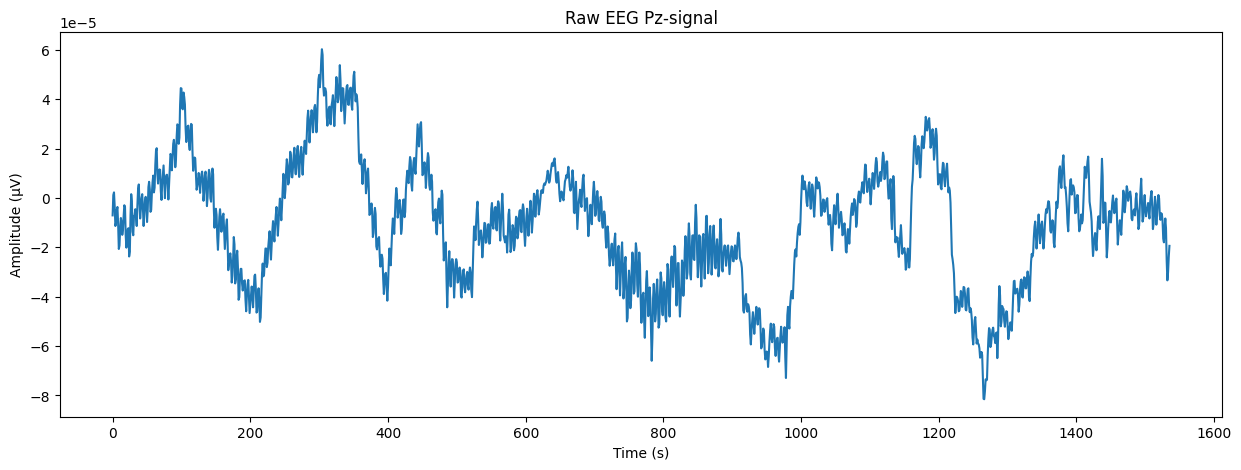

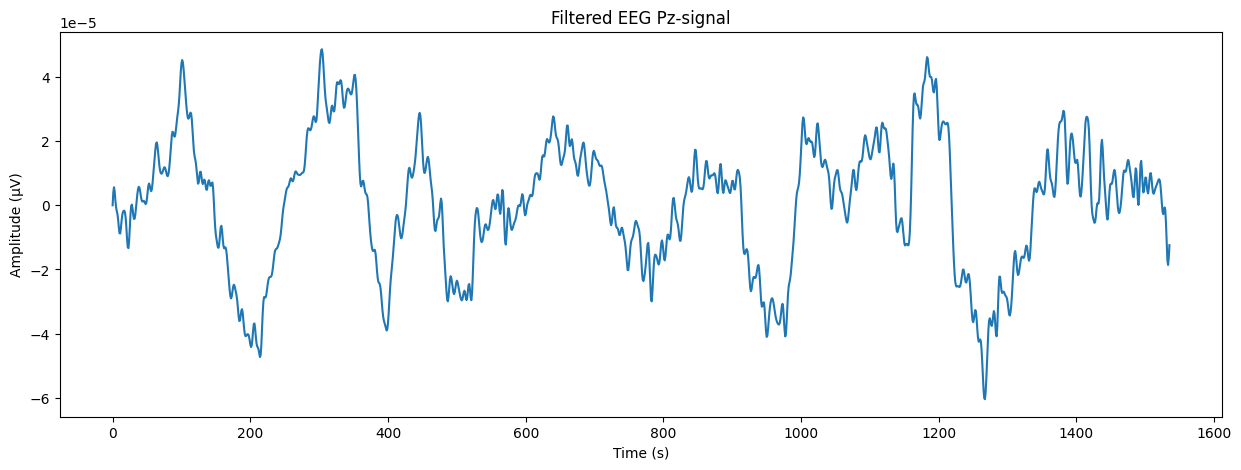

In [17]:
# View the first 15 mins of raw and filtered data
plot_eeg_signal(original_raw, 'EEG Pz',0, 6, title='Raw EEG Pz-signal', filtered=False)
plot_eeg_signal(original_raw, 'EEG Pz', 0, 6, title='Filtered EEG Pz-signal', filtered=True)

# LOAD

- Loading data by creating _patient_data_ dictionary as in '01_clustering_algo_all' notebook

In [19]:
data_files = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*.edf')))
data_files_a1 = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*annotated1.edf')))
data_files_a2 = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*annotated2.edf')))


In [20]:
print(data_files)
print(data_files_a1)
print(data_files_a2)

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE008_120418U-A.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE008_annotated1.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE008_annotated1_filtered.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_150901U-C.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_annotated1.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_annotated1_filtered.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_annotated2.edf'), WindowsPath('C:/Users/c_arz/Doc

In [24]:
raw_file = data_files_a1[1]
raw_file_0 = data_files_a1[0]
raw_file_2 = data_files_a1[2]
raw_file_3 = data_files_a1[3]

# read raw EEG data
raw_se021_a1 = mne.io.read_raw_edf(raw_file)
raw_se008_a1 = mne.io.read_raw_edf(raw_file_0)
raw_se026_a1 = mne.io.read_raw_edf(raw_file_2)
raw_se038_a1 = mne.io.read_raw_edf(raw_file_3)

In [22]:
raw_se021_a1.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F7, EEG F3, EEG Fz, EEG F4, EEG F8, EEG ...
 chs: 24 EEG
 custom_ref_applied: False
 highpass: 0.2 Hz
 lowpass: 100.0 Hz
 meas_date: 2015-09-01 16:06:27 UTC
 nchan: 24
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

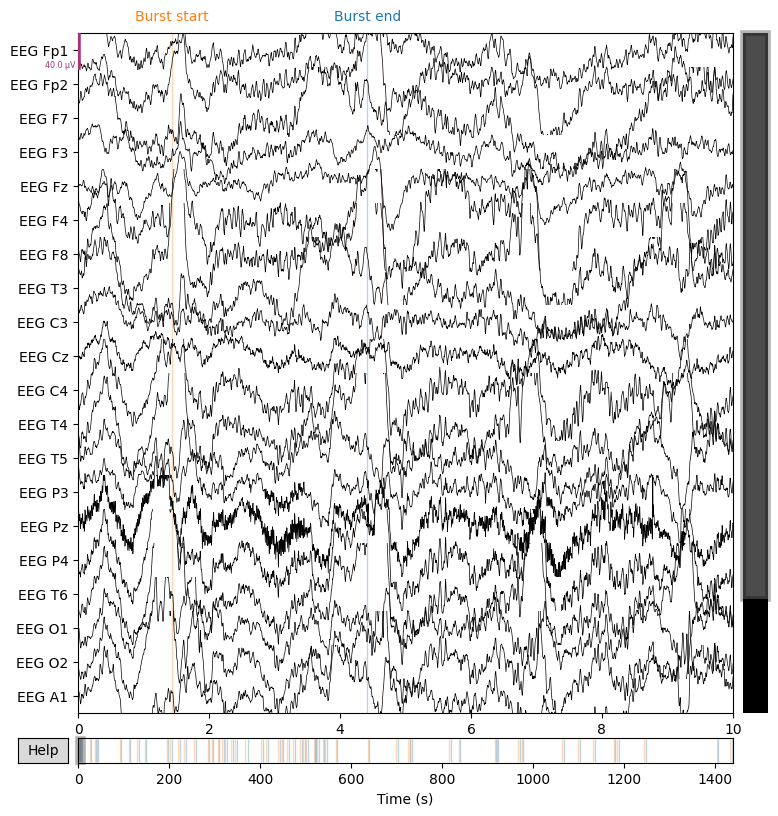

In [ ]:
raw_se021_a1.plot();

In [133]:
raw_se021_a1.info.keys()

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])

In [134]:
raw_se021_a1.info['ch_names']

['EEG Fp1',
 'EEG Fp2',
 'EEG F7',
 'EEG F3',
 'EEG Fz',
 'EEG F4',
 'EEG F8',
 'EEG T3',
 'EEG C3',
 'EEG Cz',
 'EEG C4',
 'EEG T4',
 'EEG T5',
 'EEG P3',
 'EEG Pz',
 'EEG P4',
 'EEG T6',
 'EEG O1',
 'EEG O2',
 'EEG A1',
 'EEG A2',
 'NASE',
 'EKG',
 'PHO']

In [26]:
raw_se021_a1.load_data()


<RawEDF | SE021_annotated1.edf, 24 x 368640 (1440.0 s), ~67.5 MB, data loaded>

In [ ]:
raw_se021_a1.info['']

In [27]:
raw_se008_a1.load_data()


<RawEDF | SE008_annotated1.edf, 25 x 15010560 (58635.0 s), ~2.80 GB, data loaded>

In [28]:
raw_se026_a1.load_data()


<RawEDF | SE026_annotated1.edf, 24 x 1065216 (4161.0 s), ~195.1 MB, data loaded>

In [29]:
raw_se038_a1.load_data()

<RawEDF | SE038_annotated1.edf, 24 x 1606400 (6275.0 s), ~294.2 MB, data loaded>

In [ ]:
np.mean()

In [ ]:
raw_se021_a1.describe()

<RawEDF | SE021_annotated1.edf, 24 x 368640 (1440.0 s), ~67.5 MB, data loaded>
ch  name     type  unit        min         Q1     median         Q3        max
 0  EEG Fp1  EEG   µV      -267.50      20.32      34.46      49.13     266.07
 1  EEG Fp2  EEG   µV      -201.63     109.09     128.25     147.93     470.65
 2  EEG F7   EEG   µV      -293.09      -8.14       9.75      28.91     196.98
 3  EEG F3   EEG   µV      -238.14     -99.43     -89.05     -78.13      10.47
 4  EEG Fz   EEG   µV      -201.09     104.26     115.00     126.10     428.05
 5  EEG F4   EEG   µV      -437.54    -113.39     -85.82     -58.08     158.14
 6  EEG F8   EEG   µV      -191.61      25.68      50.21      76.34     321.19
 7  EEG T3   EEG   µV      -333.54     -67.57     -47.88     -27.47     102.11
 8  EEG C3   EEG   µV      -190.53      13.51      24.79      35.71     225.79
 9  EEG Cz   EEG   µV      -148.83     -29.80     -19.78     -10.65     674.16
10  EEG C4   EEG   µV      -269.82     -51.28     -2

In [137]:
print(raw_se021_a1._data.shape)

(24, 368640)


In [138]:
raw_se021_a1.info['sfreq']

256.0

So our data were sampled at 256 Hz, meaning that there are 256 measurements per second. 

This means that each measurement is 1/256th of a second, or 3.9 ms. 

So we can derive the length of the EEG recording, in seconds, by dividing the number of time points by the sampling rate:

In [139]:
scan_durn = raw_se021_a1._data.shape[1] / raw_se021_a1.info['sfreq']
print('Duration of EEG recording = ', scan_durn, 's, or', round(scan_durn / 60, 2), 'min.')

Duration of EEG recording =  1440.0 s, or 24.0 min.


Text(0, 0.5, 'Voltage (uV)')

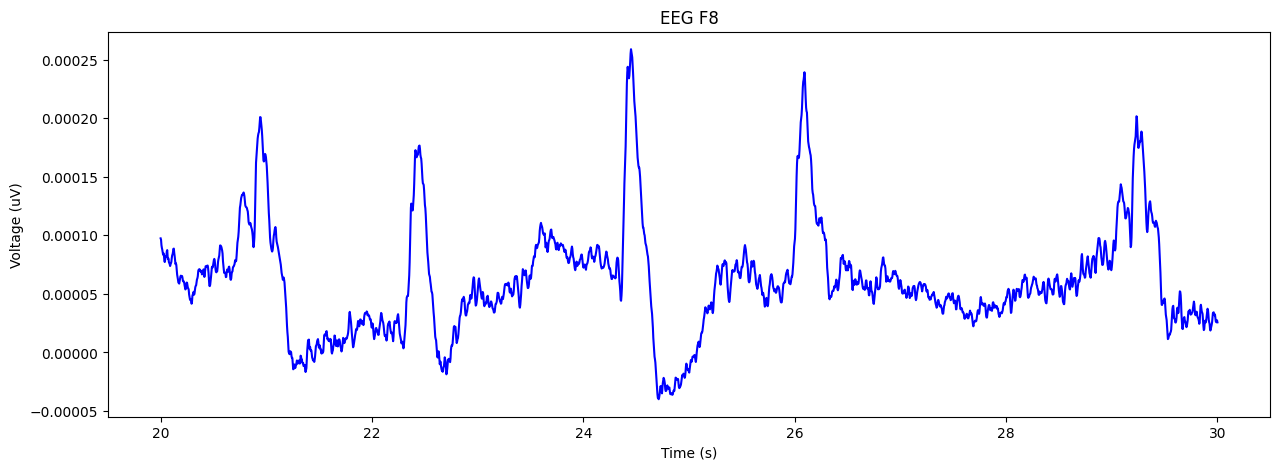

In [ ]:
channel = 'EEG F8'
start_time = 20.0    # in seconds
end_time = 30.0

# Get the data from channel Oz, from 1000 - 3000 ms
data = raw_se021_a1.get_data(picks=channel, tmin=start_time, tmax=end_time).T

# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

# Plot the data
fig, ax = plt.subplots(figsize=[15, 5])
ax.plot(times, data, color='blue')

# Label the axes
plt.title('EEG F8')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (uV)')

In [141]:
mne.events_from_annotations(raw_se021_a1)

(array([[   365,      0,      2],
        [  1130,      0,      1],
        [  6669,      0,      2],
        [  7471,      0,      1],
        [  9417,      0,      2],
        [ 10105,      0,      1],
        [ 10533,      0,      2],
        [ 11422,      0,      1],
        [ 23479,      0,      2],
        [ 24243,      0,      1],
        [ 28549,      0,      2],
        [ 29479,      0,      1],
        [ 33430,      0,      2],
        [ 34299,      0,      1],
        [ 37661,      0,      2],
        [ 38466,      0,      1],
        [ 49985,      0,      2],
        [ 50797,      0,      1],
        [ 51599,      0,      2],
        [ 52596,      0,      1],
        [ 56493,      0,      2],
        [ 57502,      0,      1],
        [ 59643,      0,      2],
        [ 60486,      0,      1],
        [ 65338,      0,      2],
        [ 66228,      0,      1],
        [ 72865,      0,      2],
        [ 73726,      0,      1],
        [ 75194,      0,      2],
        [ 7617

In [142]:
nyquist_freq = raw_se021_a1.info['sfreq'] / 2
print(f"Nyquist Frequency: {nyquist_freq}")

Nyquist Frequency: 128.0


# FILTER

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


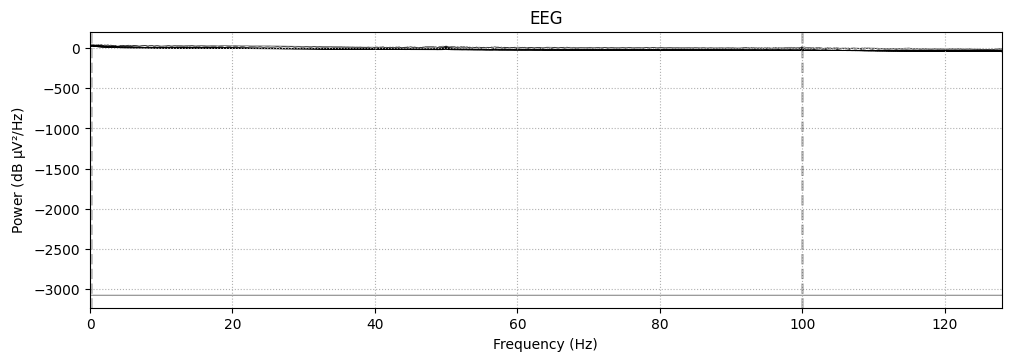

In [ ]:
raw_se021_a1.compute_psd().plot();

In [144]:
channels_to_remove = ["EEG C3", "EEG Cz", "EEG C4", "EEG P3","EEG Pz", "EEG P4",
                         "EEG A1", "EEG A2", "EKG", "PHO", "NASE"]

raw_se021_a1.drop_channels(channels_to_remove)

<RawEDF | SE021_annotated1.edf, 13 x 368640 (1440.0 s), ~36.6 MB, data loaded>

In [ ]:
raw_se021_a1.describe()

<RawEDF | SE021_annotated1.edf, 13 x 368640 (1440.0 s), ~36.6 MB, data loaded>
ch  name     type  unit        min         Q1     median         Q3        max
 0  EEG Fp1  EEG   µV      -267.50      20.32      34.46      49.13     266.07
 1  EEG Fp2  EEG   µV      -201.63     109.09     128.25     147.93     470.65
 2  EEG F7   EEG   µV      -293.09      -8.14       9.75      28.91     196.98
 3  EEG F3   EEG   µV      -238.14     -99.43     -89.05     -78.13      10.47
 4  EEG Fz   EEG   µV      -201.09     104.26     115.00     126.10     428.05
 5  EEG F4   EEG   µV      -437.54    -113.39     -85.82     -58.08     158.14
 6  EEG F8   EEG   µV      -191.61      25.68      50.21      76.34     321.19
 7  EEG T3   EEG   µV      -333.54     -67.57     -47.88     -27.47     102.11
 8  EEG T4   EEG   µV      -263.74     -52.53     -30.70      -3.31     293.99
 9  EEG T5   EEG   µV      -275.19      -2.24      15.12      32.49     191.07
10  EEG T6   EEG   µV      -429.84    -186.95    -16

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


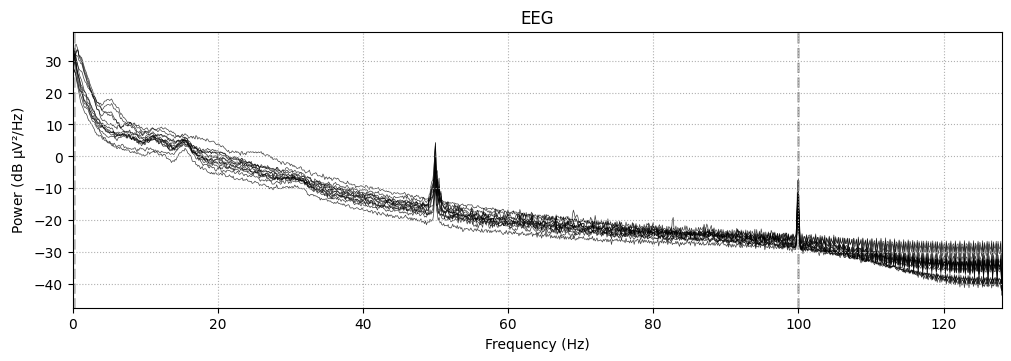

In [ ]:
raw_se021_a1.compute_psd().plot();

The PSD shows a clear spike at 50 Hz, which is the frequency of AC electrical service in Switzerland, where the data was recorded. 

This is most likely an electromagnetic interference. 

There is also a spike at 100 Hz, which is a harmonic of 50 Hz. A harmonic is a multiple of a frequency, so 100 Hz is the second harmonic of 50 Hz (50 x 2 = 100). 
We might expect a spike at the third harmonic, 150 Hz, as well.

There is also a bit of a spike around 16 Hz, which corresponds to the beta band in EEG. This is a normal frequency band in human EEG, Beta activity is commonly increased by benzodiazepines, barbiturates, and chloral hydrate.

The vertical dashed line shows the low-pass cutoff that was used during data acquisition. This information was stored in the EEG header file, and read by MNE when the data was imported.

## FILTER PARAMETERS
We define a set of parameters for the filter command first, then run it. 

The important (required) parameters are `hi_cut` and `low_cut`, and here we are specifying a bandpass filter with a low frequency (highpass) cutoff of 0.5 Hz, and a high frequency (lowpass) cutoff of 15 Hz. 

There are many other parameters that can be set, as MNE’s filtering function is quite robust. However, the defaults for these parameters have been set to already be optimized for most EEG and MEG data.

We need to chain the `.copy()` and `.filter()` methods because by default, the `.filter()` method modifies the raw data in-place, rather than creating a new, filtered copy of the data. 

This is sensible for managing the memory used, but can create problems if we want to change the filter settings and redo the filtering step.

In [147]:
low_cut = 0.5
hi_cut  = 15
iir_params = dict(order=18, ftype='cheby1', rp=0.1, rs=None, output='sos')

raw_se021_a1_filt = raw_se021_a1.copy().filter(low_cut, hi_cut, method='iir', iir_params=iir_params)

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


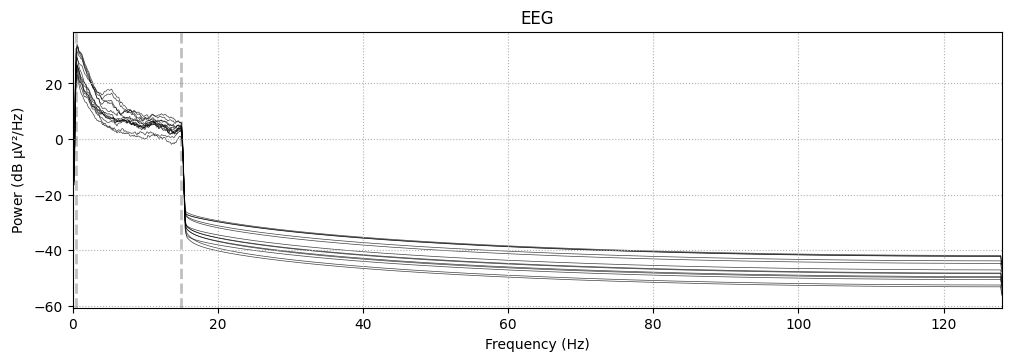

In [148]:
raw_se021_a1_filt.compute_psd().plot();

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


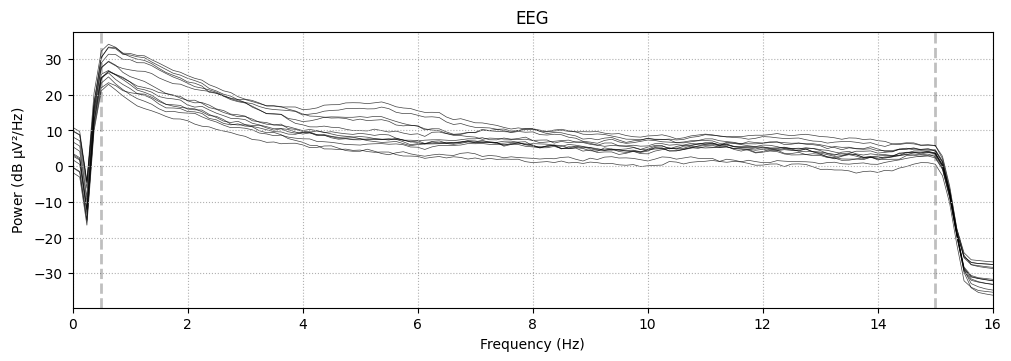

In [149]:
raw_se021_a1_filt.compute_psd(fmax=16).plot();

Note that for both the high- and low-pass filters, the power does not drop of sharply right at the cutoff frequency we specified. 

Rather, there is a roll-off — a range of frequencies over which the power gradually decreases. 

The shape of the roll-off is a property of the filter that is determined by its parameters, and some roll-off is a necessary feature of any filter if aftifacts are to be avoided. 

Again, this is a deep topic that we won’t delve into here, but in general it is useful to remember the adage that precision in the frequency domain is inversely related to precision in the time domain. 

In other words, if we use a sharper frequency cutoff, we are likely to induce larger artifacts in the data, when we view the filtered data in the time domain.

Text(0, 0.5, 'Voltage (uV)')

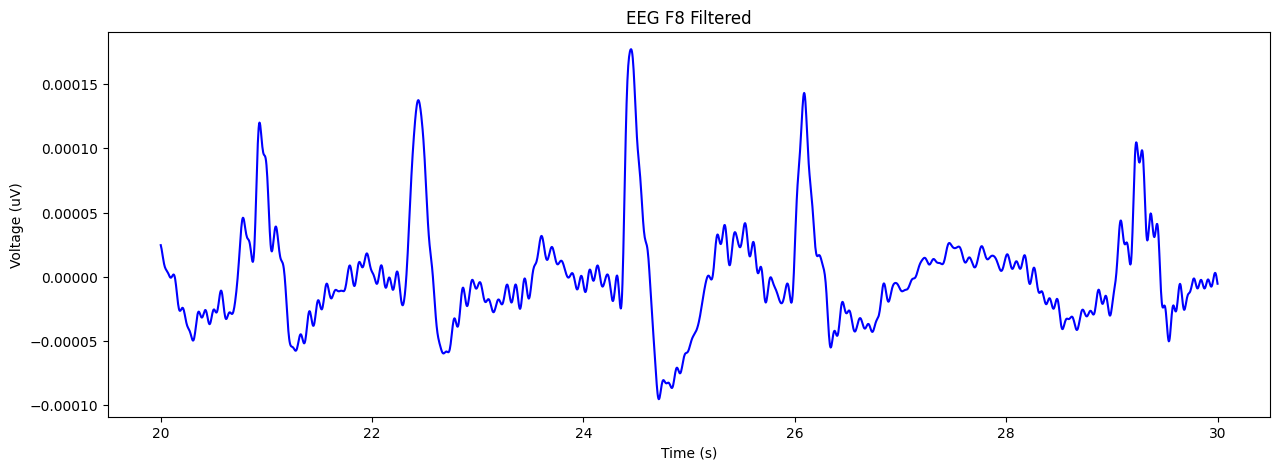

In [150]:
channel = 'EEG F8'
start_time = 20.0    # in seconds
end_time = 30.0

# Get the data from channel Oz, from 1000 - 3000 ms
data = raw_se021_a1_filt.get_data(picks=channel, tmin=start_time, tmax=end_time).T

# Get the time values
times = np.linspace(start_time, end_time, num=data.shape[0])

# Plot the data
fig, ax = plt.subplots(figsize=[15, 5])
ax.plot(times, data, color='blue')

# Label the axes
plt.title('EEG F8 Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (uV)')

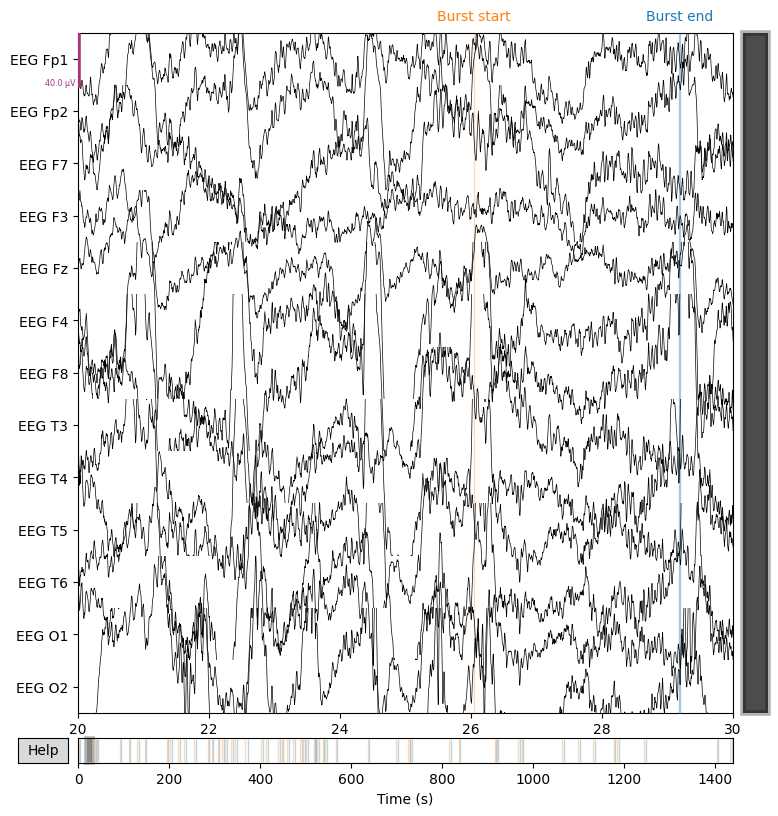

In [ ]:
raw_se021_a1.plot(start=20, duration=10);

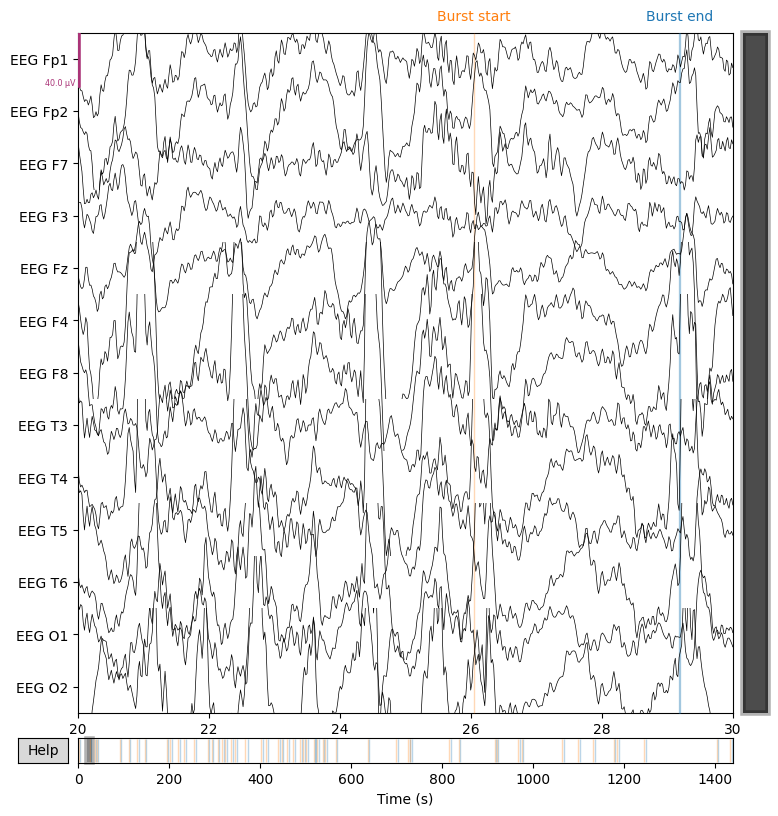

In [152]:
raw_se021_a1_filt.plot(start=20, duration=10);

In [ ]:
low_cut = 0.5
hi_cut  = 15
# 16=Highest order of Chebyshev type 1 filter without BadCoefficients Error: 
# "Badly conditioned filter coefficients (numerator): the results may be meaningless b, a = normalize(b, a)""

iir_params = dict(order=16, ftype='cheby1', rp=0.1, rs=None, output='sos')
raw_se021_a1_filt2 = raw_se021_a1.copy().filter(low_cut, hi_cut, method='iir', iir_params=iir_params)

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


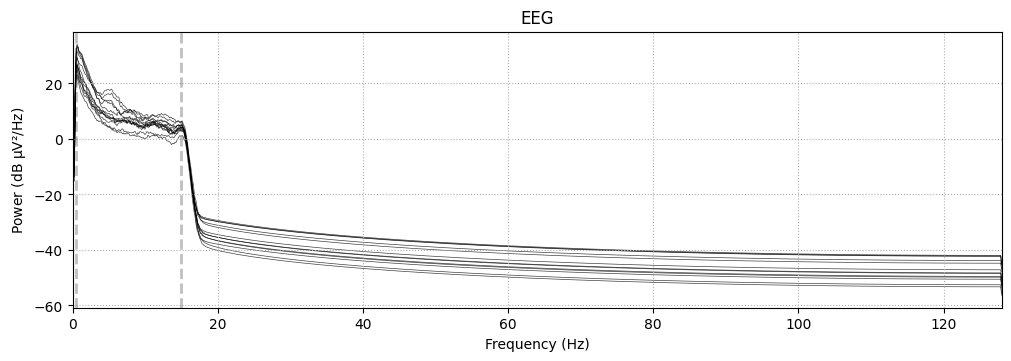

In [156]:
raw_se021_a1_filt2.compute_psd().plot();

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


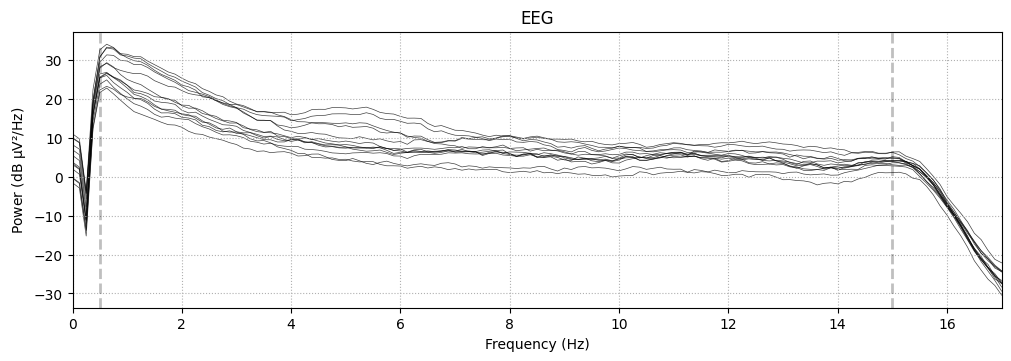

In [ ]:
raw_se021_a1_filt2.compute_psd(fmax=16).plot();

## SAVE FILTERED DATA

In [154]:
print(raw_se021_a1_filt.filenames)

('C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\SE021_annotated1.edf',)


In [155]:
mne.export.export_raw('SE021_a1_filt.edf', raw_se021_a1_filt, fmt='edf', overwrite=True)

FileExistsError: Destination file exists. Please use option "overwrite=True" to force overwriting.

In [18]:
patient_data = {}

for file in tqdm.tqdm(data_files):
    patient_id = file.stem.split("_")[0]
    data = mne.io.read_raw_edf(file)
    
    fs = data.loc[patient_id, "sample_rate"]
    patient_data[patient_id] = {'data': data, 'fs': fs}

NameError: name 'tqdm' is not defined